In [60]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import pandas as pd
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any
from obspy.signal.filter import envelope
from enveloc.core import XCOR
from obspy.clients.fdsn import Client
from obspy.core.util import AttribDict
import numpy as np
from obspy import Stream
import matplotlib.pyplot as plt
import os
import obspy
import shutil
from obspy import Stream

In [61]:
def conv_to_datetime(df):
    new_df = []
    for i in range(len(df)):
        year = int(df[i].split('_')[0])
        month = int(df[i].split('_')[1])
        day = int(df[i].split('_')[2].split(' ')[0])
        hour = int(df[i].split('_')[2].split(' ')[1][0:2])
        minute = int(df[i].split('_')[2].split(' ')[1][2:4])
        second = int(df[i].split('_')[2].split(' ')[1][4:])
        new_df.append(obspy.UTCDateTime(year, month, day, hour, minute, second))
        
    return np.array(new_df)

## Loading Mount Rainier Catalog

In [62]:
client = Client('IRIS')
mt_rainier_cat = pd.read_csv('../src/mount_rainier_events_from_esec.txt', sep = '|')

In [63]:
mt_rainier_cat['starttime'] = conv_to_datetime(mt_rainier_cat['starttime'])
mt_rainier_cat['endtime'] = conv_to_datetime(mt_rainier_cat['endtime'])

In [64]:
pd.set_option('display.max_columns', None)
mt_rainier_cat

,areaSource,areaSourceHigh,areaSourceLow,areaTotal,associationId,datlocation,depth,endtime,eventid,h,hHigh,hLow,hfall,hfall_high,hfall_low,l,lHigh,lLow,latitude,locuncertKm,longitude,lppotential,mass,massHigh,massLow,maxdistvhfKm,maxdistvhfReached,maxdisthfKm,maxdisthfReached,maxdistipKm,maxdistipReached,maxdistlpKm,maxdistlpReached,maxdistinfraKm,maxdistinfraReached,infraDetected,name,otherdataquality1to5,peakDischarge,peakDischargeLow,peakDischargeHigh,peakFlowheight,peakFlowheightLow,peakFlowheightHigh,starttime,sources,toeLat,toeLon,topLat,topLon,upstreamDrainarea,type,subtype,volume,volumeHigh,volumeLow
0,NaN,NaN,NaN,NaN,120,IRIS,NaN,2011-07-06T22:25:35.000000Z,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,100.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 10,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-07-06T22:23:27.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,71000.0,100000.0,52000.0
1,NaN,NaN,NaN,NaN,122,IRIS,NaN,1989-08-16T17:15:09.000000Z,122,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,181.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 2, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:14:09.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,82,IRIS,NaN,2014-02-25T13:43:28.000000Z,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.83720,0.20,-121.75070,0,NaN,NaN,NaN,NaN,NaN,15.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Mount Rainier,3,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-25T13:39:24.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,ice avalanche,Rock/ice/debris avalanches and slides,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,118,IRIS,NaN,2011-06-29T03:43:04.000000Z,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,13.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 6,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-29T03:42:04.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,12000.0,17000.0,8600.0
4,50000.0,75000.0,45000.0,550000.0,25,IRIS,NaN,2011-06-25T15:21:53.000000Z,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,133.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 2,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-25T15:20:42.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,37000.0,53000.0,27000.0
5,NaN,NaN,NaN,NaN,335,IRIS,NaN,2023-12-10T19:08:08.000000Z,335,1300.0,1500.0,900.0,NaN,NaN,NaN,2900.0,3200.0,2700.0,46.86120,0.00,-121.73900,0,NaN,NaN,NaN,NaN,NaN,78.0,True,NaN,NaN,0.0,NaN,9.0,True,True,"Emmons Glacier, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-10T19:04:45.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.87390,-121.70690,46.86120,-121.73900,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,121,IRIS,NaN,1989-08-16T17:07:08.000000Z,121,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,91.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 1, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:06:19.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
7,NaN,NaN,NaN,200000.0,179,IRIS,NaN,2021-03-11T22:59:19.000000Z,179,600.0,NaN,NaN,NaN,NaN,NaN,1200.0,NaN,NaN,46.85850,0.35,-121.78570,0,NaN,NaN,NaN,NaN,NaN,12.0,True,NaN,NaN,0.0,NaN,0.0,NaN,False,"Sunset Amphitheater, Mount Rainier",2,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-11T22:58:14.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.85350,-121.79910,46.86100,-121.78720,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
8,NaN,NaN,NaN

In [65]:
## just for general exams purpose. 
#mt_rainier_cat = mt_rainier_cat.iloc[19:21].reset_index(drop=True)

In [66]:
ev_lats = mt_rainier_cat['latitude']
ev_lons = mt_rainier_cat['longitude']
ev_starttimes = mt_rainier_cat['starttime']
ev_endtimes = mt_rainier_cat['endtime']
ev_types = mt_rainier_cat['type']
ev_subtypes = mt_rainier_cat['subtype']
ev_evids = mt_rainier_cat['eventid']
ev_locuncerts = mt_rainier_cat['locuncertKm']
ev_dataqualities = mt_rainier_cat['otherdataquality1to5']
ev_names = mt_rainier_cat['name']

### Seismic data quality
- 1 = seismic detection but no visual documentation; 
- 2 = photographic documentation;
- 3 = media reports, non-peer reviewed scientific reports, and/or inclusion in broad peer-reviewed scientific study; 

- 4 = satellite imagery available; 
- 5 = detailed peer-reviewed scientific study

Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 10



Event Information
Event name Nisqually 10
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 120
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.07.06 22:22:47  --  2011.07.06 22:27:05
--Location--
Latitude: 46.822, Longitude: -121.717, Depth: 0.0 km


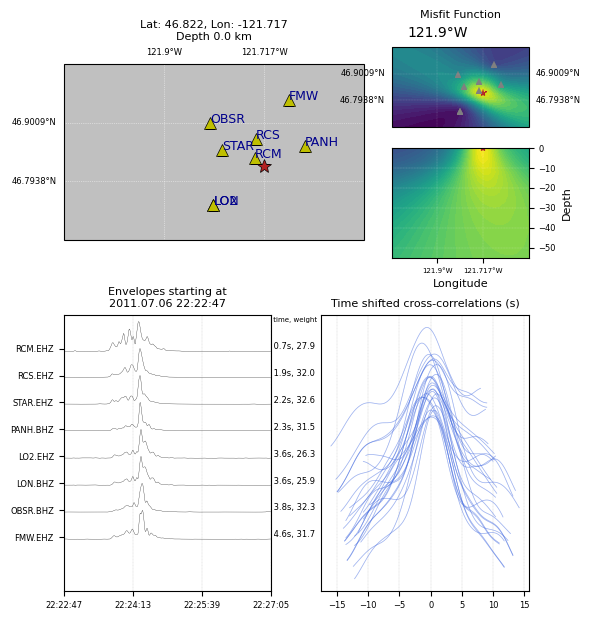

-121.71664888666666 46.82198330578947


Found 6 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 5
  Failed: 6

Failed downloads:
  - UW.FMW..SHZ
  - UW.LO2..SHZ
  - UW.LON..SHZ
  - UW.RCS..SHZ
  - UW.RER..SHZ
  - UW.RVC..SHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 5
High SNR traces (>10): 4



Event Information
Event name Russell Cliff 2, Mount Rainier
Event type rock fall
Event Subtype Rock/debris falls
Event ID 122
Location Uncertainty (Km) 0.5
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


1989.08.16 17:14:10  --  1989.08.16 17:16:12
--Location--
Latitude: 46.822, Longitude: -121.718, Depth: 11.6 km


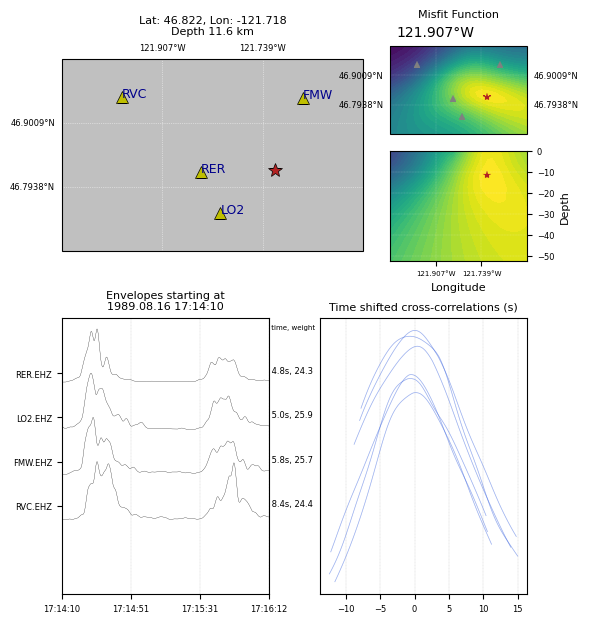

-121.71813510416666 46.8219839368421


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 9



Event Information
Event name Mount Rainier
Event type ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 82
Location Uncertainty (Km) 0.2
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2014.02.25 13:38:44  --  2014.02.25 13:44:58
--Location--
Latitude: 46.855, Longitude: -121.756, Depth: 0.0 km


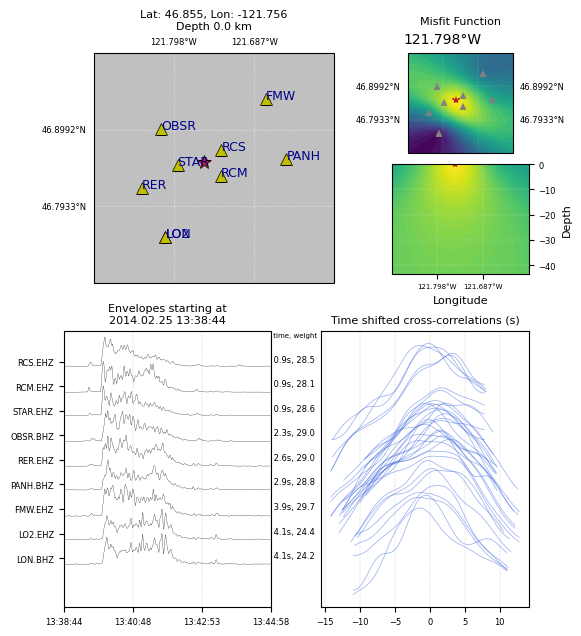

-121.75637297 46.85461394473684


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 6
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 118
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.06.29 03:41:24  --  2011.06.29 03:44:34
--Location--
Latitude: 46.838, Longitude: -121.765, Depth: 0.0 km


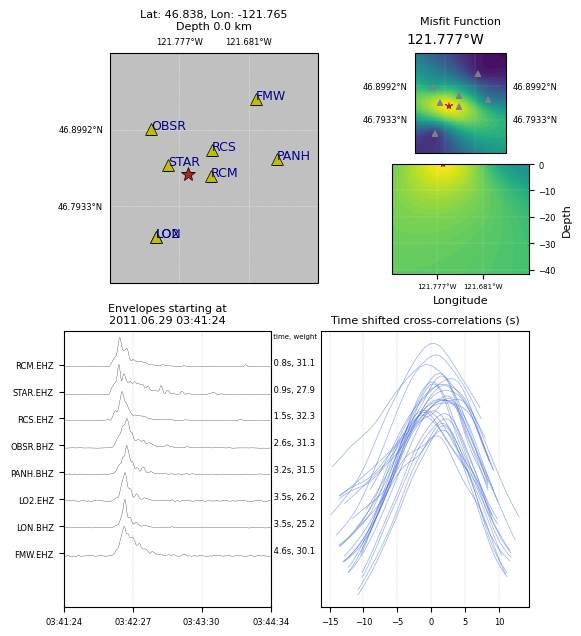

-121.7648048425 46.83789905526316


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 2
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 25
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.06.25 15:20:02  --  2011.06.25 15:23:23
--Location--
Latitude: 46.838, Longitude: -121.741, Depth: 0.0 km


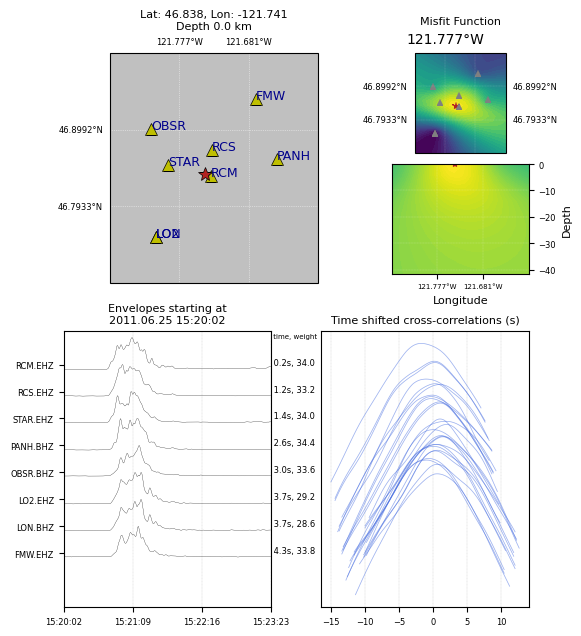

-121.74090928083334 46.83789905526316


Found 26 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 26
  Failed: 13

Failed downloads:
  - CC.ARAT..CHZ
  - CC.COPP..CHZ
  - CC.CRBN..CHZ
  - CC.GTWY..CHZ
  - CC.KAUT..CHZ
  - CC.MILD..CHZ
  - CC.OPCH..CHZ
  - CC.PARA..CHZ
  - CC.PR05..CHZ
  - CC.SIFT..CHZ
  - CC.TABR..CHZ
  - CC.TAVI..CHZ
  - CC.WOW..CHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 26
High SNR traces (>10): 17



Event Information
Event name Emmons Glacier, Mount Rainier
Event type snow avalanche
Event Subtype Snow avalanches
Event ID 335
Location Uncertainty (Km) 0.0
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2023.12.10 19:04:05  --  2023.12.10 19:06:25
--Location--
Latitude: 46.849, Longitude: -121.719, D

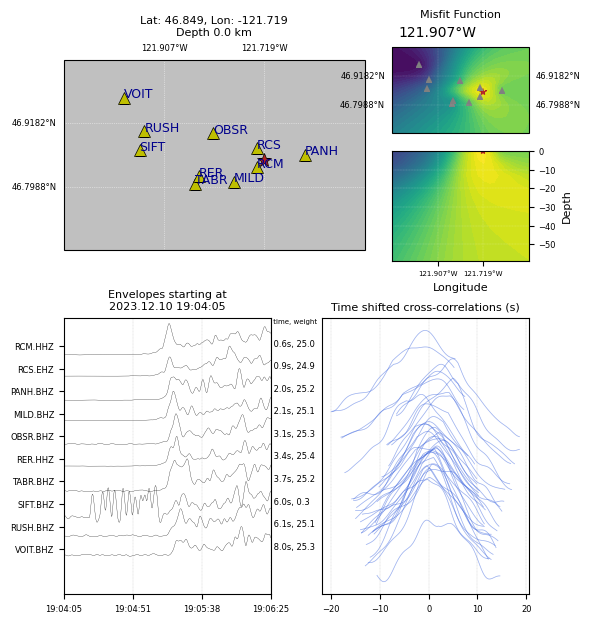

-121.71867898666666 46.849054151052634


Found 6 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 5
  Failed: 6

Failed downloads:
  - UW.FMW..SHZ
  - UW.LO2..SHZ
  - UW.LON..SHZ
  - UW.RCS..SHZ
  - UW.RER..SHZ
  - UW.RVC..SHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 5
High SNR traces (>10): 0
Found 23 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 22
  Failed: 1

Failed downloads:
  - CC.PR02..BHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 22
High SNR traces (>10): 6



Event Information
Event name Sunset Amphitheater, Mount Rainier
Event type snow avalanche
Event Subtype Snow avalanches
Event ID 179
Location Uncertainty (Km) 0.35
Data Quality 2




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid 

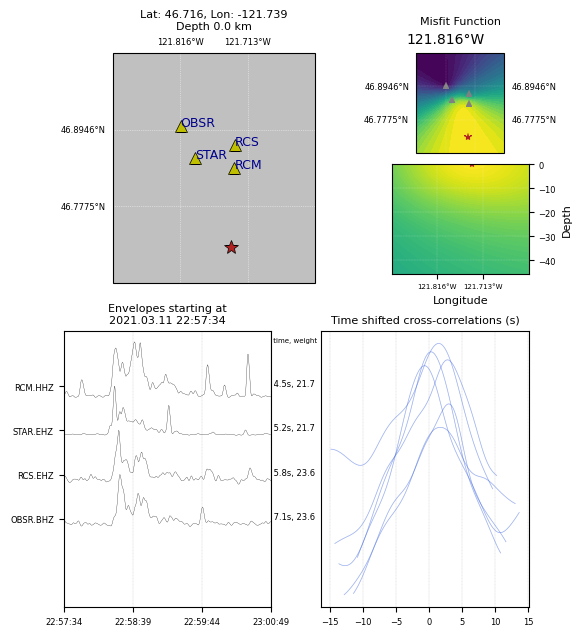

-121.73870462 46.71589301105263


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 7
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 29
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.07.01 23:29:25  --  2011.07.01 23:37:57
--Location--
Latitude: 46.855, Longitude: -121.729, Depth: 0.0 km


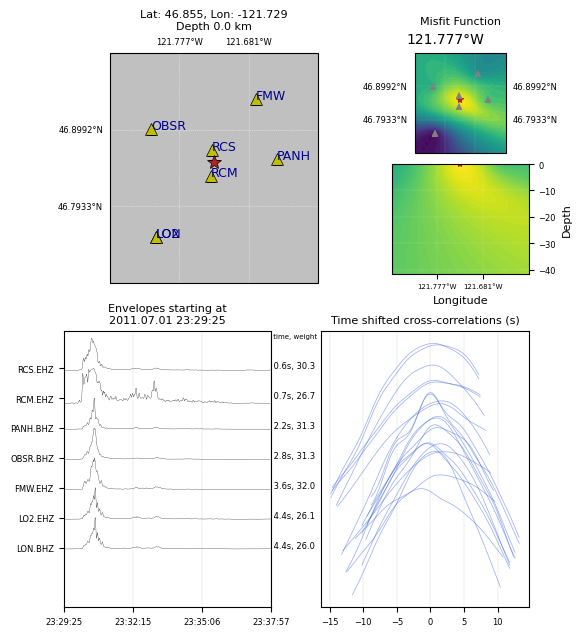

-121.7289615 46.85461394473684


Found 17 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 15
  Failed: 2

Failed downloads:
  - CC.PANH..BHZ
  - UW.RER..EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 15
High SNR traces (>10): 6



Event Information
Event name Nisqually, Mount Rainier 2
Event type ice fall
Event Subtype Rock/debris falls
Event ID 291
Location Uncertainty (Km) 0.1
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2021.09.13 17:45:56  --  2021.09.13 17:48:55
nan nan


Found 29 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 29
  Failed: 13

Failed downloads:
  - CC.ARAT..CHZ
  - CC.COPP..CHZ
  - CC.CRBN..CHZ
  - CC.GTWY..CHZ
  - CC.KAUT..CHZ
  - CC.MILD..CHZ
  - CC.OPCH..BHZ
  - CC.OPCH..CHZ
  - CC.PARA..CHZ
  - CC.PR05..CHZ
  - CC.TABR..CHZ
  - CC.TAVI..CHZ
  - CC.WOW..CHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 32
High SNR traces (>10): 19



Event Information
Event name Willis Wall, Mount Rainier
Event type ice fall
Event Subtype Rock/debris falls
Event ID 332
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2023.05.28 17:17:58  --  2023.05.28 17:21:49
--Location--
Latitude: 46.859, Longitude: -121.789, Depth: 0

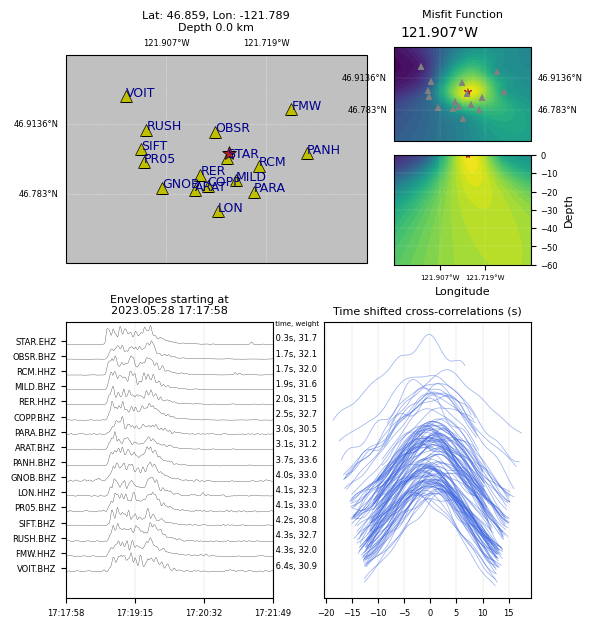

-121.78937174666666 46.85862521105263


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 8
  Failed: 4

Failed downloads:
  - CC.PANH..BHZ
  - UW.FMW.01.EHZ
  - UW.RCM..EHZ
  - UW.STAR.01.EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 41
High SNR traces (>10): 26



Event Information
Event name Mount Rainier
Event type outburst flood, debris flow
Event Subtype Lahar/debris flow/outburst flood
Event ID 32
Location Uncertainty (Km) 13.0
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2015.08.13 16:49:08  --  2015.08.13 18:28:16
WARNING FROM XC_locate: too many traces with peaks at edge of window
nan nan


Found 19 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 17
  Failed: 2

Failed downloads:
  - CC.PR05..BHZ
  - CC.VOIT..BHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 23
High SNR traces (>10): 13



Event Information
Event name Carbon Glacier, Mount Rainier
Event type snow avalanche
Event Subtype Snow avalanches
Event ID 176
Location Uncertainty (Km) 0.3
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2020.04.09 13:28:01  --  2020.04.09 13:31:24
--Location--
Latitude: 46.859, Longitude: -121.749, Depth: 0.0 km


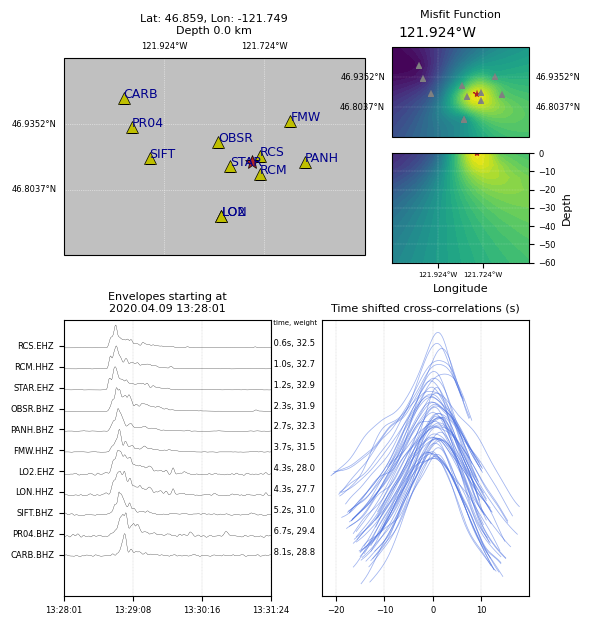

-121.748716265 46.85907484578947


Found 17 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 17
  Failed: 1

Failed downloads:
  - UW.RVC..EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 17
High SNR traces (>10): 12



Event Information
Event name Tahoma Creek, Mount Rainier
Event type outburst flood, debris flow
Event Subtype Lahar/debris flow/outburst flood
Event ID 178
Location Uncertainty (Km) 0.2
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2019.08.06 01:43:52  --  2019.08.06 03:14:04
--Location--
Latitude: 46.855, Longitude: -121.755, Depth: 17.6 km


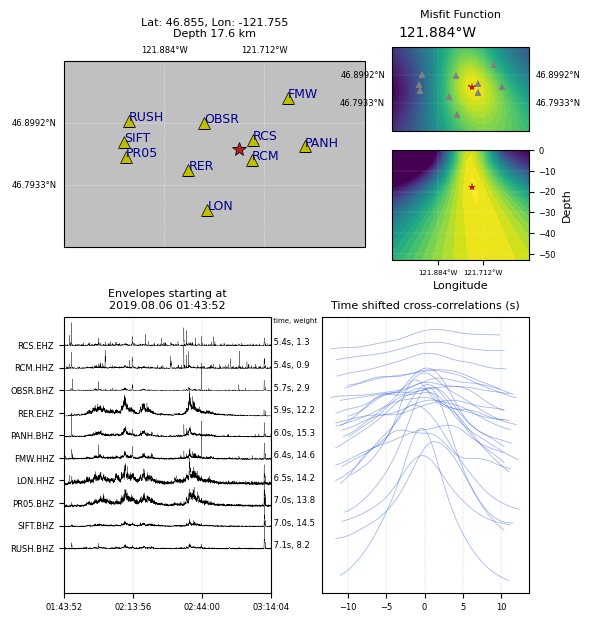

-121.75496111 46.85461394473684


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 9



Event Information
Event name Nisqually 1
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 83
Location Uncertainty (Km) 0.0
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.06.24 16:40:14  --  2011.06.24 16:46:29
--Location--
Latitude: 46.839, Longitude: -121.740, Depth: 0.0 km


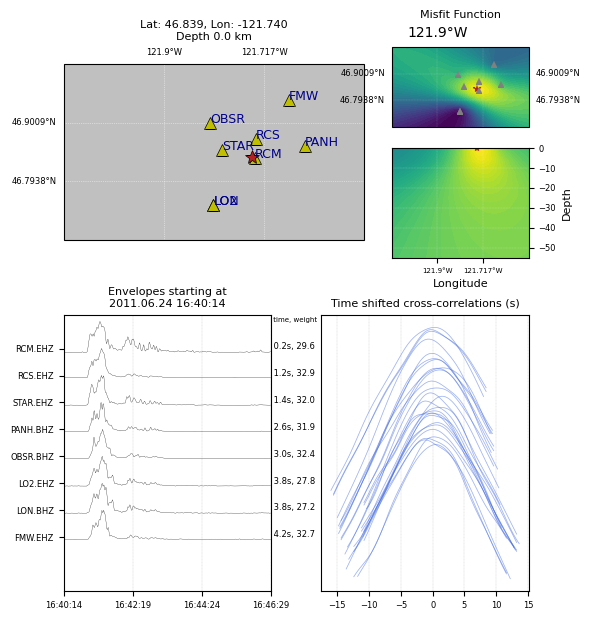

-121.739584415 46.83888743526316


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 8
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 119
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.07.02 16:24:56  --  2011.07.02 16:28:50
--Location--
Latitude: 46.871, Longitude: -121.729, Depth: 18.5 km


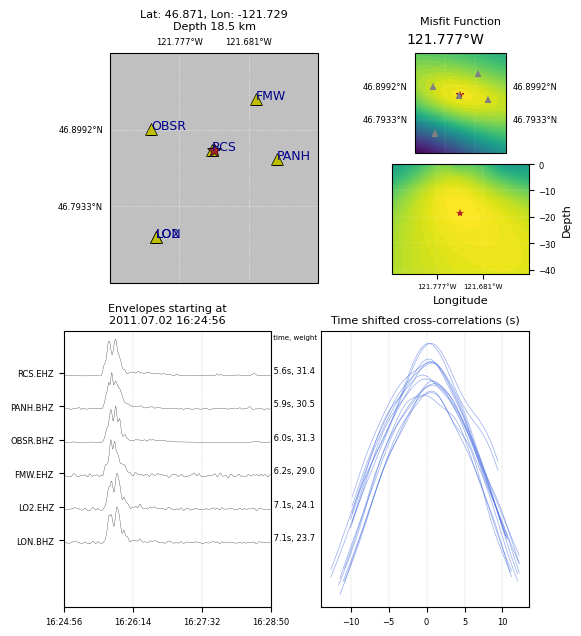

-121.7289615 46.87132883421052


Found 6 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 5
  Failed: 6

Failed downloads:
  - UW.FMW..SHZ
  - UW.LO2..SHZ
  - UW.LON..SHZ
  - UW.RCS..SHZ
  - UW.RER..SHZ
  - UW.RVC..SHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 5
High SNR traces (>10): 4



Event Information
Event name Russell Cliff 3, Mount Rainier
Event type rock fall
Event Subtype Rock/debris falls
Event ID 123
Location Uncertainty (Km) 0.5
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


1989.08.16 17:14:43  --  1989.08.16 17:16:12
--Location--
Latitude: 46.839, Longitude: -121.739, Depth: 5.8 km


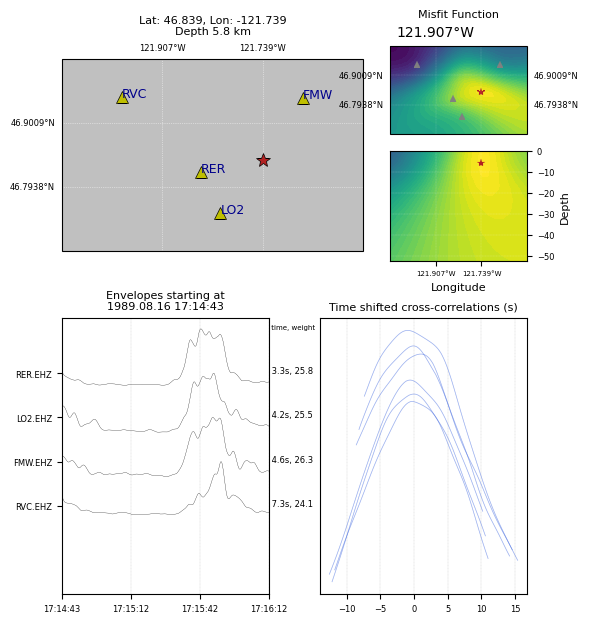

-121.73907358333334 46.83888797894737


Found 11 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 9
  Failed: 4

Failed downloads:
  - CC.SR41..EHZ
  - UW.FMW.01.EHZ
  - UW.RCM..EHZ
  - UW.STAR.01.EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 11
High SNR traces (>10): 8



Event Information
Event name Mount Rainier
Event type rock fall
Event Subtype Rock/debris falls
Event ID 36
Location Uncertainty (Km) 1.0
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2015.08.19 18:49:10  --  2015.08.19 18:53:06
--Location--
Latitude: 46.838, Longitude: -121.756, Depth: 0.0 km


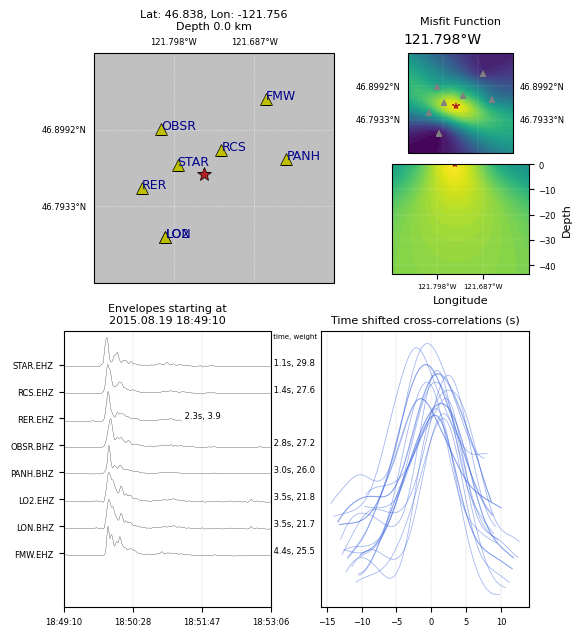

-121.75637297 46.83789905526316


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 4
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 27
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.06.26 01:28:11  --  2011.06.26 01:36:31
--Location--
Latitude: 46.838, Longitude: -121.741, Depth: 0.0 km


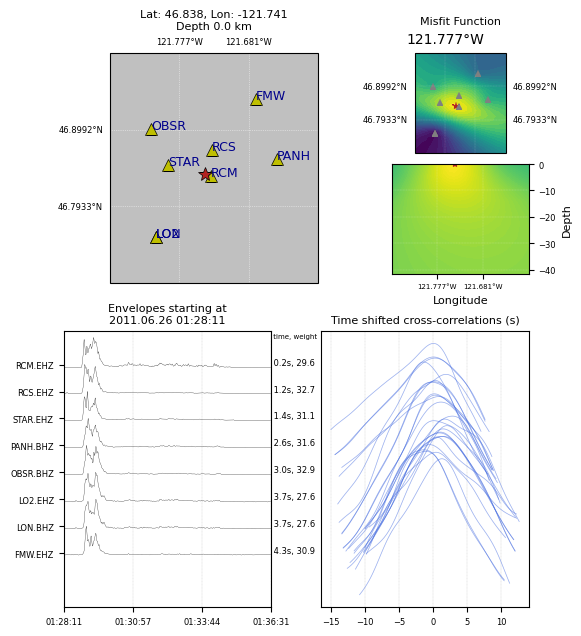

-121.74090928083334 46.83789905526316


Found 24 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 23
  Failed: 14

Failed downloads:
  - CC.ARAT..CHZ
  - CC.COPP..CHZ
  - CC.GTWY..CHZ
  - CC.KAUT..CHZ
  - CC.MILD..CHZ
  - CC.OPCH..CHZ
  - CC.PARA..CHZ
  - CC.PR04..CHZ
  - CC.PR05..CHZ
  - CC.SIFT..CHZ
  - CC.TABR..CHZ
  - CC.TAVI..CHZ
  - CC.WOW..CHZ
  - UW.STAR.01.EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 23
High SNR traces (>10): 16



Event Information
Event name Nisqually, Mount Rainier
Event type ice fall, snow avalanche
Event Subtype Snow avalanches
Event ID 327
Location Uncertainty (Km) 0.1
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2024.02.10 20:02:43  --  2024.02.10 20:06:43
--Location--
Latitude: 46.855

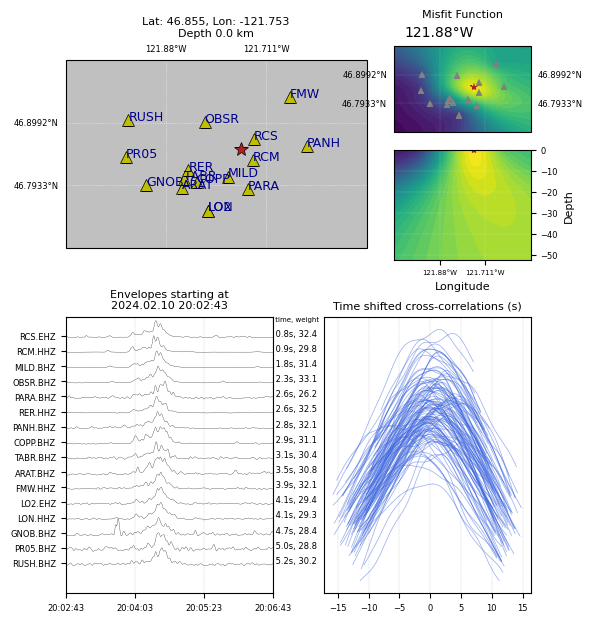

-121.75336001166666 46.85461394473684


Found 6 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 5
  Failed: 6

Failed downloads:
  - UW.FMW..SHZ
  - UW.LO2..SHZ
  - UW.LON..SHZ
  - UW.RCS..SHZ
  - UW.RER..SHZ
  - UW.RVC..SHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 5
High SNR traces (>10): 0
Found 18 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 12
  Failed: 7

Failed downloads:
  - CC.PR01..BHZ
  - CC.PR02..BHZ
  - CC.PR03..BHZ
  - CC.PR04..BHZ
  - CC.PR05..BHZ
  - CC.VOIT..BHZ
  - UW.RVC..EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 13
High SNR traces (>10): 11



Event Information
Event name Mount Rainier
Event type debris flow
Event Subtype Lahar/debris flow/outburst flood
Event ID 175
Location Uncertainty (Km) 3.0
Data Quality 1




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/minicond

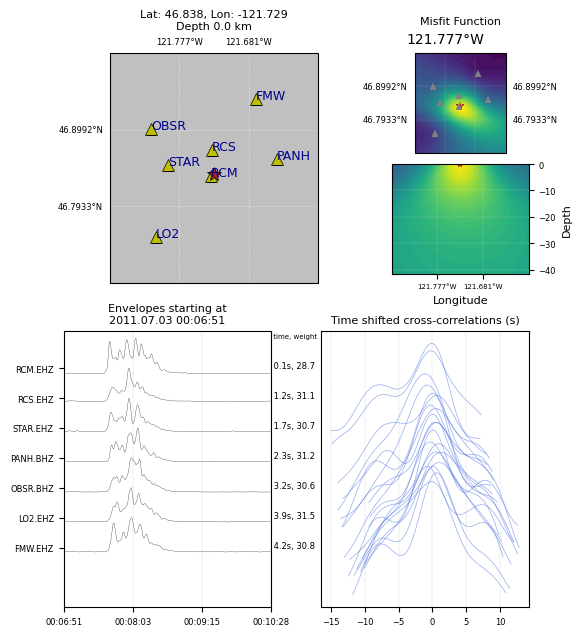

-121.7289615 46.83789959894737


Found 6 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 5
  Failed: 7

Failed downloads:
  - UW.FMW..SHZ
  - UW.LO2..SHZ
  - UW.LON..BHZ
  - UW.LON..SHZ
  - UW.RCS..SHZ
  - UW.RER..SHZ
  - UW.RVC..SHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 5
High SNR traces (>10): 0
Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 7
  Failed: 3

Failed downloads:
  - CC.OBSR..BHZ
  - CC.PANH..BHZ
  - UW.LON..BHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 7
High SNR traces (>10): 4



Event Information
Event name Mount Rainier
Event type snow avalanche
Event Subtype Snow avalanches
Event ID 62
Location Uncertainty (Km) 0.2
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model

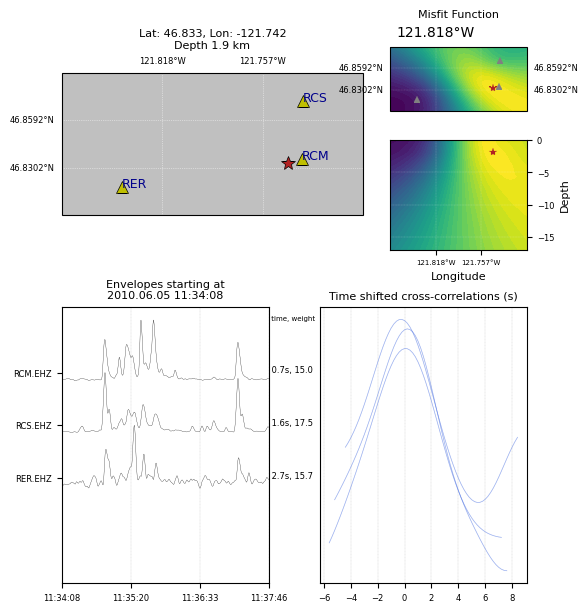

-121.74167615 46.8332925


Found 10 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 10
  Failed: 0

Station inventory saved to waveforms/station_inventory.xml
Original traces: 10
High SNR traces (>10): 8



Event Information
Event name Nisqually 3
Event type rock fall, rock and ice avalanche
Event Subtype Rock/ice/debris avalanches and slides
Event ID 26
Location Uncertainty (Km) 0.2
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.06.25 23:03:25  --  2011.06.25 23:12:45
--Location--
Latitude: 46.838, Longitude: -121.741, Depth: 0.0 km


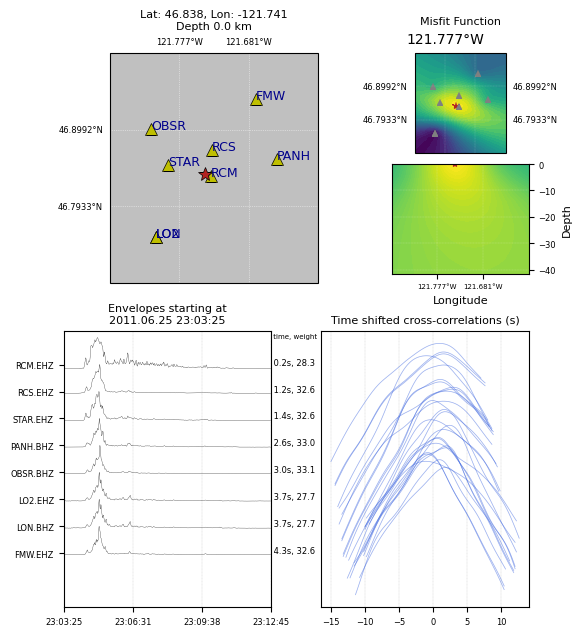

-121.74090928083334 46.83789905526316


Found 29 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 30
  Failed: 11

Failed downloads:
  - CC.ARAT..CHZ
  - CC.COPP..CHZ
  - CC.CRBN..CHZ
  - CC.GTWY..CHZ
  - CC.KAUT..CHZ
  - CC.MILD..CHZ
  - CC.OPCH..CHZ
  - CC.PARA..CHZ
  - CC.PR05..CHZ
  - CC.TAVI..CHZ
  - CC.WOW..CHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 31
High SNR traces (>10): 20



Event Information
Event name Tahoma Creek, Mount Rainier
Event type outburst flood, debris flow
Event Subtype Lahar/debris flow/outburst flood
Event ID 320
Location Uncertainty (Km) 0.1
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2023.08.15 23:22:36  --  2023.08.16 00:08:28
Found 10 stations
Deleted existing directory: waveforms
Cre

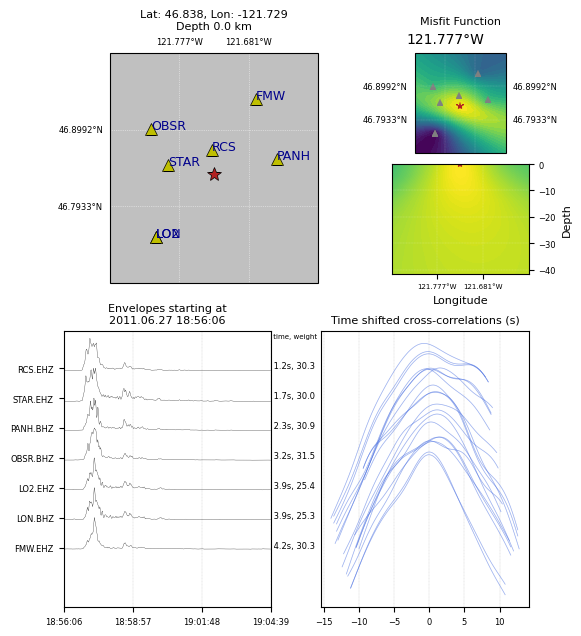

-121.7289615 46.83789905526316


Found 12 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 13
  Failed: 1

Failed downloads:
  - CC.PANH..BHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 13
High SNR traces (>10): 10



Event Information
Event name Ingraham Glacier, Mount Rainier
Event type ice fall
Event Subtype Rock/debris falls
Event ID 128
Location Uncertainty (Km) 0.5
Data Quality 3




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2018.07.07 05:37:34  --  2018.07.07 05:42:44
--Location--
Latitude: 46.821, Longitude: -121.714, Depth: 0.0 km


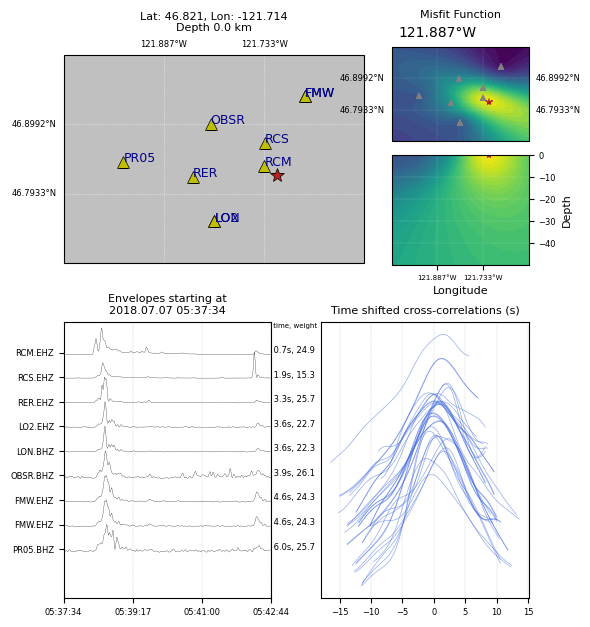

-121.71423052499999 46.821184165789475


Found 17 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 15
  Failed: 2

Failed downloads:
  - CC.PANH..BHZ
  - UW.RER..EHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 15
High SNR traces (>10): 9



Event Information
Event name Nisqually, Mount Rainier 1
Event type ice fall
Event Subtype Rock/debris falls
Event ID 290
Location Uncertainty (Km) 0.1
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2021.09.13 17:15:27  --  2021.09.13 17:18:24
--Location--
Latitude: 46.850, Longitude: -121.743, Depth: 0.0 km


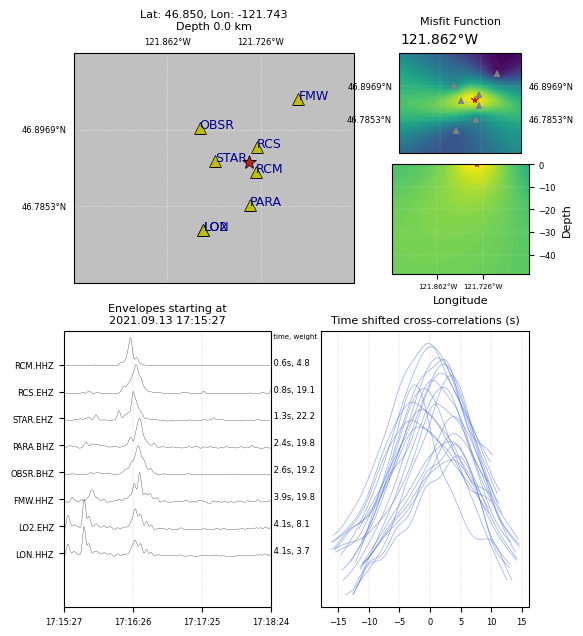

-121.7432740425 46.84987236736842


Found 19 stations
Deleted existing directory: waveforms
Created directory: waveforms


Download Summary:
  Successful: 18
  Failed: 1

Failed downloads:
  - CC.VOIT..BHZ

Station inventory saved to waveforms/station_inventory.xml
Original traces: 18
High SNR traces (>10): 16



Event Information
Event name Liberty Cap Glacier, Mount Rainier
Event type rock and ice fall
Event Subtype Rock/debris falls
Event ID 177
Location Uncertainty (Km) 0.1
Data Quality 4




Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2020.07.16 04:25:23  --  2020.07.16 04:28:27
--Location--
Latitude: 46.859, Longitude: -121.784, Depth: 0.0 km


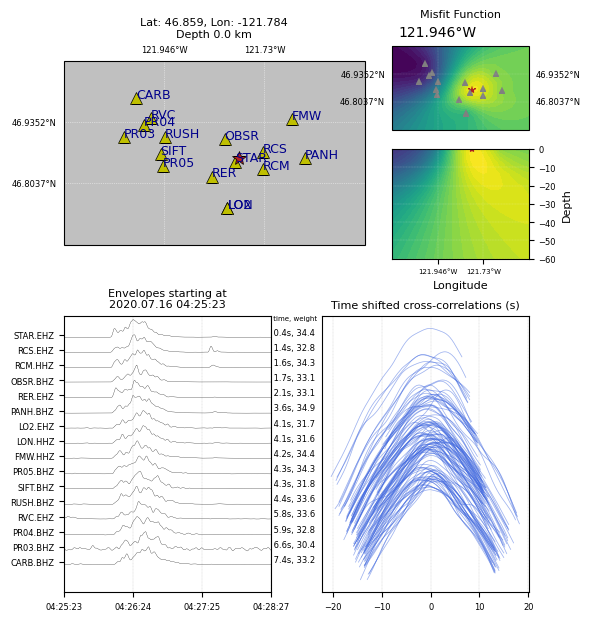

-121.783677805 46.85907484578947


In [67]:
# enveloc coordinates
enveloc_lats = []
enveloc_lons = []
enveloc_evids = []



FREQMIN = 1.0 # minimum frequency
FREQMAX = 8.0 # maximum frequency
LOWPASS = 0.2 # lowpass for envelope smoothing
DT = 10       # seconds of padding


for i in range(len(ev_lats)):
    
    
    try:
    
        # downloading stations within given radius 


        # Initialize client
        client = Client("IRIS")

        # Get stations
        inventory = client.get_stations(
            latitude= ev_lats[i],
            longitude= ev_lons[i], 
            starttime= ev_starttimes[i] - 12*3600,
            endtime= ev_endtimes[i] + 12*3600, 
            minradius=0, 
            maxradius=0.2, 
            level='response', 
            network='CC,UW',
            location='*', 
            channel='*HZ'
        )

        print(f"Found {len(inventory.get_contents()['stations'])} stations")




        # downloading waveform data.

        # Define time window for waveform data
        starttime = ev_starttimes[i] - 50
        endtime = ev_endtimes[i] + 100

        # Create directory to save waveforms
        output_dir = "waveforms"

        # Delete the directory if it exists, then recreate it
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)
            print(f"Deleted existing directory: {output_dir}")

        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}\n")

        # Download waveforms for each station
        successful_downloads = 0
        failed_downloads = []

        for network in inventory:
            for station in network:
                for channel in station:
                    # Only get vertical components (HZ channels)
                    if channel.code.endswith('HZ'):
                        try:
                            print(f"Downloading {network.code}.{station.code}.{channel.location_code}.{channel.code}...")

                            # Get waveform
                            st = client.get_waveforms(
                                network=network.code,
                                station=station.code,
                                location=channel.location_code,
                                channel=channel.code,
                                starttime=starttime,
                                endtime=endtime
                            )

                            # Save to file
                            filename = f"{network.code}.{station.code}.{channel.location_code}.{channel.code}.mseed"
                            filepath = os.path.join(output_dir, filename)
                            st.write(filepath, format='MSEED')

                            #print(f"  ✓ Saved: {filename}")
                            successful_downloads += 1

                        except Exception as e:
                            error_msg = f"{network.code}.{station.code}.{channel.location_code}.{channel.code}"
                            #print(f"  ✗ Failed: {error_msg} - {str(e)}")
                            failed_downloads.append(error_msg)

        # Summary
        print(f"\n{'='*60}")
        print(f"Download Summary:")
        print(f"  Successful: {successful_downloads}")
        print(f"  Failed: {len(failed_downloads)}")
        if failed_downloads:
            print(f"\nFailed downloads:")
            for fail in failed_downloads:
                print(f"  - {fail}")

        # Save inventory
        inventory.write(os.path.join(output_dir, "station_inventory.xml"), format="STATIONXML")
        print(f"\nStation inventory saved to {output_dir}/station_inventory.xml")




        # computing locations

        st = obspy.read('waveforms/*.mseed')
        st_filt = st.copy()
        st_filt.detrend("demean")
        st_filt.taper(max_percentage = None, max_length = 5)
        st_filt.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=3, zerophase=True)



        # filtering for high snr stations

        # Create a new stream to store high SNR traces
        high_snr_stream = Stream()

        for j in range(len(st_filt)):
            snr = abs(max(st_filt[j].data)) / np.mean(abs(st_filt[j].data))

            # Only keep traces with SNR > 10
            if snr > 10:
                high_snr_stream.append(st_filt[j])

                #plt.figure(figsize = [10,3])
                #plt.title(f'SNR {snr:.2f}')
                #plt.plot(st_filt[i].data / abs(max(st_filt[i].data)))

        print(f"Original traces: {len(st_filt)}")
        print(f"High SNR traces (>10): {len(high_snr_stream)}")

        # Now high_snr_stream contains only traces with SNR > 10
        # You can save it or continue processing
        high_snr_stream.write("high_snr_traces.mseed", format='MSEED')




        # build envelopes from filtered waveforms (recommended: envelope AFTER bandpass)
        st_env = high_snr_stream.copy()
        for tr in st_env:
            if tr.stats.npts % 2 == 1:
                tr.trim(tr.stats.starttime, tr.stats.endtime + 1/tr.stats.sampling_rate,
                        pad=True, fill_value=0)
            tr.data = envelope(tr.data)
            tr.resample(5.0)

        st_env.filter("lowpass", freq=LOWPASS)

        # trim both to remove taper effects (keep them comparable)
        t1 = st_filt[0].stats.starttime + DT
        t2 = st_filt[0].stats.endtime - DT
        st_filt.trim(t1, t2)
        st_env.trim(t1, t2)




        for tr in st_env:
            inventory = client.get_stations(
                network=tr.stats.network, station=tr.stats.station,
                location=tr.stats.location, channel=tr.stats.channel,
                starttime=tr.stats.starttime, endtime=tr.stats.endtime
            )
            tr.stats.coordinates = AttribDict({
                "latitude":  inventory[0][0].latitude,
                "longitude": inventory[0][0].longitude,
                "elevation": inventory[0][0].elevation
            })  


        print()
        print()
        print()
        print('Event Information') 
        print(f'Event name {ev_names[i]}')
        print(f'Event type {ev_types[i]}')  
        print(f'Event Subtype {ev_subtypes[i]}') 
        print(f'Event ID {ev_evids[i]}')
        print(f'Location Uncertainty (Km) {ev_locuncerts[i]}')
        print(f'Data Quality {ev_dataqualities[i]}')
        print()
        print()
        print()
        print()
        


        XC = XCOR(st_env, plot = True,  interact= False)
        loc = XC.locate()


        actual_lon, actual_lat = ev_lons[i], ev_lats[i]
        import plotly.graph_objects as go

        import plotly.io as pio
        pio.renderers.default = "notebook_connected"  # best bet for many JupyterHub setups


        # Define your region
        region = [-123, -121, 46, 48]  # [lon_min, lon_max, lat_min, lat_max]

        # Create figure
        fig = go.Figure()

        # Add the solution star (event location)
        # --- Event "star" replacement: outlined bullseye (always renders) ---
        event_lon, event_lat =  loc.longitude, loc.latitude
        
        enveloc_lons.append(event_lon)
        enveloc_lats.append(event_lat)
        enveloc_evids.append(ev_evids[i])
        print(event_lon, event_lat)

        # outline
        fig.add_trace(go.Scattermapbox(
            lon=[event_lon],
            lat=[event_lat],
            mode='markers',
            marker=dict(size=28, color='black'),
            name='Event (outline)',
            showlegend=False,
            hoverinfo='skip'
        ))

        # fill
        fig.add_trace(go.Scattermapbox(
            lon=[event_lon],
            lat=[event_lat],
            mode='markers',
            marker=dict(size=20, color='yellow'),
            name='Enveloc Event Location',
            hovertemplate='<b>Event</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
        ))




        # fill
        fig.add_trace(go.Scattermapbox(
            lon=[actual_lon],
            lat=[actual_lat],
            mode='markers',
            marker=dict(size=20, color='green'),
            name='Actual (verified) Event Location',
            hovertemplate='<b>Event</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
        ))




        # Add stations (if you have station data)
        # Example station coordinates - replace with your actual data
        stations_lon = [st_env[i].stats.coordinates.longitude for i in range(len(st_env))]
        stations_lat = [st_env[i].stats.coordinates.latitude for i in range(len(st_env))]
        station_names = [st_env[i].stats.station for i in range(len(st_env))]

        fig.add_trace(go.Scattermapbox(
            lon=stations_lon,
            lat=stations_lat,
            mode='markers+text',
            marker=dict(
                size=14,
                color='red',
                symbol='triangle-up'
            ),
            marker_symbol = 'circle',
            text=station_names,
            textposition='top right',          # try: 'middle right', 'bottom right', etc.
            textfont=dict(size=12, color='black'),
            name='Stations',
            hovertemplate='<b>%{text}</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
        ))


        # Update layout with terrain basemap
        fig.update_layout(
            title='Event & Used Stations',
            mapbox=dict(
                style='stamen-terrain',  # Terrain style (free, no token needed)
                center=dict(
                    lon= event_lon,  # Center longitude
                    lat= event_lat   # Center latitude
                ),
                zoom=8.5,  # Adjust zoom level
            ),
            height=700,
            width=900,
            showlegend=True,
            legend=dict(
                x=0.98,
                y=0.98,
                xanchor='right',
                yanchor='top',
                bgcolor='rgba(255, 255, 255, 0.8)',
                bordercolor='gray',
                borderwidth=1
            )
        )

        fig.update_layout(mapbox_style="open-street-map")
        fig.show()
        fig.write_html('maps_html/icefall_general_exam.html')
        
    except:
        pass
    

In [58]:
# 2024-02-10 20:03:23

In [33]:
enveloc_evids

[np.int64(120),
 np.int64(122),
 np.int64(82),
 np.int64(118),
 np.int64(25),
 np.int64(335),
 np.int64(179),
 np.int64(29),
 np.int64(291),
 np.int64(332),
 np.int64(32),
 np.int64(176),
 np.int64(178),
 np.int64(83),
 np.int64(119),
 np.int64(123),
 np.int64(36),
 np.int64(27),
 np.int64(327),
 np.int64(30),
 np.int64(62),
 np.int64(26),
 np.int64(28),
 np.int64(128),
 np.int64(290),
 np.int64(177)]

In [34]:
mt_rainier_cat

,areaSource,areaSourceHigh,areaSourceLow,areaTotal,associationId,datlocation,depth,endtime,eventid,h,hHigh,hLow,hfall,hfall_high,hfall_low,l,lHigh,lLow,latitude,locuncertKm,longitude,lppotential,mass,massHigh,massLow,maxdistvhfKm,maxdistvhfReached,maxdisthfKm,maxdisthfReached,maxdistipKm,maxdistipReached,maxdistlpKm,maxdistlpReached,maxdistinfraKm,maxdistinfraReached,infraDetected,name,otherdataquality1to5,peakDischarge,peakDischargeLow,peakDischargeHigh,peakFlowheight,peakFlowheightLow,peakFlowheightHigh,starttime,sources,toeLat,toeLon,topLat,topLon,upstreamDrainarea,type,subtype,volume,volumeHigh,volumeLow
0,NaN,NaN,NaN,NaN,120,IRIS,NaN,2011-07-06T22:25:35.000000Z,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,100.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 10,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-07-06T22:23:27.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,71000.0,100000.0,52000.0
1,NaN,NaN,NaN,NaN,122,IRIS,NaN,1989-08-16T17:15:09.000000Z,122,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,181.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 2, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:14:09.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,82,IRIS,NaN,2014-02-25T13:43:28.000000Z,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.83720,0.20,-121.75070,0,NaN,NaN,NaN,NaN,NaN,15.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Mount Rainier,3,NaN,NaN,NaN,NaN,NaN,NaN,2014-02-25T13:39:24.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,ice avalanche,Rock/ice/debris avalanches and slides,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,118,IRIS,NaN,2011-06-29T03:43:04.000000Z,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,13.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 6,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-29T03:42:04.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,12000.0,17000.0,8600.0
4,50000.0,75000.0,45000.0,550000.0,25,IRIS,NaN,2011-06-25T15:21:53.000000Z,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.84300,0.20,-121.75000,0,NaN,NaN,NaN,NaN,NaN,133.0,True,NaN,NaN,0.0,NaN,NaN,NaN,NaN,Nisqually 2,4,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-25T15:20:42.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",46.82050,-121.73790,46.84300,-121.75000,NaN,"rock fall, rock and ice avalanche",Rock/ice/debris avalanches and slides,37000.0,53000.0,27000.0
5,NaN,NaN,NaN,NaN,335,IRIS,NaN,2023-12-10T19:08:08.000000Z,335,1300.0,1500.0,900.0,NaN,NaN,NaN,2900.0,3200.0,2700.0,46.86120,0.00,-121.73900,0,NaN,NaN,NaN,NaN,NaN,78.0,True,NaN,NaN,0.0,NaN,9.0,True,True,"Emmons Glacier, Mount Rainier",4,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-10T19:04:45.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.87390,-121.70690,46.86120,-121.73900,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,121,IRIS,NaN,1989-08-16T17:07:08.000000Z,121,2300.0,NaN,NaN,NaN,NaN,NaN,7800.0,NaN,NaN,46.87460,0.50,-121.75370,0,NaN,NaN,NaN,NaN,NaN,91.0,False,NaN,NaN,0.0,NaN,NaN,NaN,NaN,"Russell Cliff 1, Mount Rainier",3,NaN,NaN,NaN,NaN,NaN,NaN,1989-08-16T17:06:19.000000Z,"Allstadt, Kate E., McVey, Brennah G., and Malo...",NaN,NaN,NaN,NaN,NaN,rock fall,Rock/debris falls,NaN,NaN,NaN
7,NaN,NaN,NaN,200000.0,179,IRIS,NaN,2021-03-11T22:59:19.000000Z,179,600.0,NaN,NaN,NaN,NaN,NaN,1200.0,NaN,NaN,46.85850,0.35,-121.78570,0,NaN,NaN,NaN,NaN,NaN,12.0,True,NaN,NaN,0.0,NaN,0.0,NaN,False,"Sunset Amphitheater, Mount Rainier",2,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-11T22:58:14.000000Z,"Collins, E.A., Allstadt, K.E., Groult, C., Hib...",46.85350,-121.79910,46.86100,-121.78720,NaN,snow avalanche,Snow avalanches,NaN,NaN,NaN
8,NaN,NaN,NaN

9 Trace(s) in Stream:
CC.OBSR..BHZ | 2011-07-06T22:22:37.000000Z - 2011-07-06T22:27:15.000000Z | 50.0 Hz, 13901 samples
CC.PANH..BHZ | 2011-07-06T22:22:37.000000Z - 2011-07-06T22:27:15.000000Z | 50.0 Hz, 13901 samples
UW.FMW..EHZ  | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples
UW.LO2..EHZ  | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples
UW.LON..BHZ  | 2011-07-06T22:22:37.015000Z - 2011-07-06T22:27:14.995000Z | 50.0 Hz, 13900 samples
UW.RCM..EHZ  | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples
UW.RCS..EHZ  | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples
UW.RER..EHZ  | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples
UW.STAR..EHZ | 2011-07-06T22:22:37.009900Z - 2011-07-06T22:27:14.999900Z | 100.0 Hz, 27800 samples

Original traces: 9
High SNR traces (>10): 9


9 Trace(s) in Stream:
CC.OBSR..BHZ | 2011-07-06T22:22:47.000000Z - 2011-07-06T22:27:05.000000Z | 5.0 Hz, 1291 samples
CC.PANH..BHZ | 2011-07-06T22:22:47.000000Z - 2011-07-06T22:27:05.000000Z | 5.0 Hz, 1291 samples
UW.FMW..EHZ  | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples
UW.LO2..EHZ  | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples
UW.LON..BHZ  | 2011-07-06T22:22:47.015000Z - 2011-07-06T22:27:05.015000Z | 5.0 Hz, 1291 samples
UW.RCM..EHZ  | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples
UW.RCS..EHZ  | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples
UW.RER..EHZ  | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples
UW.STAR..EHZ | 2011-07-06T22:22:47.009900Z - 2011-07-06T22:27:05.009900Z | 5.0 Hz, 1291 samples

Warning!  No model provided.
Default model used. Maybe not ideal...
Using /home/ak287/miniconda3/envs/enveloc/lib/python3.11/site-packages/enveloc/default_vel_model.tvel
Warning!  No grid provided.
Making grid based on stations provided...


2011.07.06 22:22:47  --  2011.07.06 22:27:05
--Location--
Latitude: 46.821, Longitude: -121.715, Depth: 0.0 km


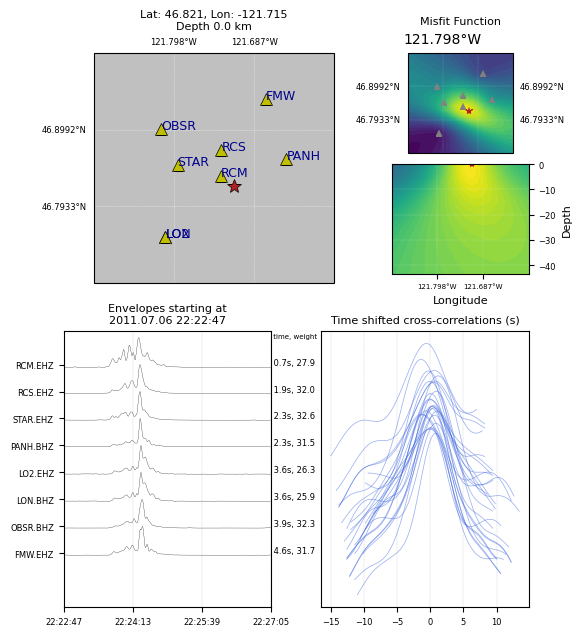

In [135]:

#XC = XCOR(env, grid_size=mygrid, plot = True,  interact= False)

XC = XCOR(st_env, plot = True,  interact= False)
loc = XC.locate()


In [136]:
actual_lon, actual_lat = ev_lons[i], ev_lats[i]
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "notebook_connected"  # best bet for many JupyterHub setups


# Define your region
region = [-123, -121, 46, 48]  # [lon_min, lon_max, lat_min, lat_max]

# Create figure
fig = go.Figure()

# Add the solution star (event location)
# --- Event "star" replacement: outlined bullseye (always renders) ---
event_lon, event_lat =  loc.longitude, loc.latitude

print(event_lon, event_lat)

# outline
fig.add_trace(go.Scattermapbox(
    lon=[event_lon],
    lat=[event_lat],
    mode='markers',
    marker=dict(size=28, color='black'),
    name='Event (outline)',
    showlegend=False,
    hoverinfo='skip'
))

# fill
fig.add_trace(go.Scattermapbox(
    lon=[event_lon],
    lat=[event_lat],
    mode='markers',
    marker=dict(size=20, color='yellow'),
    name='Enveloc Event Location',
    hovertemplate='<b>Event</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
))




# fill
fig.add_trace(go.Scattermapbox(
    lon=[actual_lon],
    lat=[actual_lat],
    mode='markers',
    marker=dict(size=20, color='green'),
    name='Actual (verified) Event Location',
    hovertemplate='<b>Event</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
))




# Add stations (if you have station data)
# Example station coordinates - replace with your actual data
stations_lon = [st_env[i].stats.coordinates.longitude for i in range(len(st_env))]
stations_lat = [st_env[i].stats.coordinates.latitude for i in range(len(st_env))]
station_names = [st_env[i].stats.station for i in range(len(st_env))]

fig.add_trace(go.Scattermapbox(
    lon=stations_lon,
    lat=stations_lat,
    mode='markers+text',
    marker=dict(
        size=14,
        color='red',
        symbol='triangle-up'
    ),
    marker_symbol = 'circle',
    text=station_names,
    textposition='top right',          # try: 'middle right', 'bottom right', etc.
    textfont=dict(size=12, color='black'),
    name='Stations',
    hovertemplate='<b>%{text}</b><br>Lon: %{lon:.3f}<br>Lat: %{lat:.3f}<extra></extra>'
))


# Update layout with terrain basemap
fig.update_layout(
    title='Event & Used Stations',
    mapbox=dict(
        style='stamen-terrain',  # Terrain style (free, no token needed)
        center=dict(
            lon= event_lon,  # Center longitude
            lat= event_lat   # Center latitude
        ),
        zoom=8.5,  # Adjust zoom level
    ),
    height=700,
    width=900,
    showlegend=True,
    legend=dict(
        x=0.98,
        y=0.98,
        xanchor='right',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='gray',
        borderwidth=1
    )
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

-121.71489206 46.821184165789475
